In [8]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

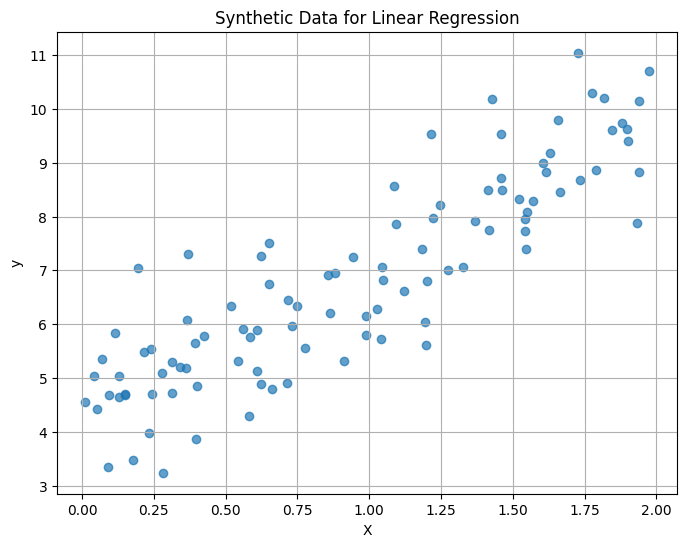

In [9]:
# Generate some synthetic data
X = 2 * np.random.rand(100, 1) # 100 random numbers between 0 and 2
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3X + noise

# Plot the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.7)
plt.title('Synthetic Data for Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

In [10]:
# Initialize model parameters (weight and bias)
w = np.random.randn(1, 1)
b = np.random.randn(1, 1)

print(f"Initial weight (w): {w[0][0]:.4f}")
print(f"Initial bias (b): {b[0][0]:.4f}")

Initial weight (w): 0.0130
Initial bias (b): 1.4535


In [11]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [12]:
def gradient_descent(X, y, w, b, learning_rate):
    # Calculate predictions
    y_pred = X @ w + b

    # Calculate gradients of the MSE loss with respect to w and b
    dW = -2 * np.mean(X * (y - y_pred))
    db = -2 * np.mean(y - y_pred)

    # Update parameters
    w = w - learning_rate * dW
    b = b - learning_rate * db

    return w, b

In [13]:
epochs = 100
learning_rate = 0.01

losses = []

for epoch in range(epochs):
    # Update parameters using gradient descent
    w, b = gradient_descent(X, y, w, b, learning_rate)

    # Make predictions with current parameters
    y_pred = X @ w + b

    # Calculate and store the loss
    loss = mean_squared_error(y, y_pred)
    losses.append(loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}")

print(f"\nFinal weight (w): {w[0][0]:.4f}")
print(f"Final bias (b): {b[0][0]:.4f}")

Epoch 10/100, Loss: 14.2901
Epoch 20/100, Loss: 6.6117
Epoch 30/100, Loss: 3.3083
Epoch 40/100, Loss: 1.8870
Epoch 50/100, Loss: 1.2753
Epoch 60/100, Loss: 1.0119
Epoch 70/100, Loss: 0.8983
Epoch 80/100, Loss: 0.8492
Epoch 90/100, Loss: 0.8279
Epoch 100/100, Loss: 0.8186

Final weight (w): 2.8426
Final bias (b): 4.0463


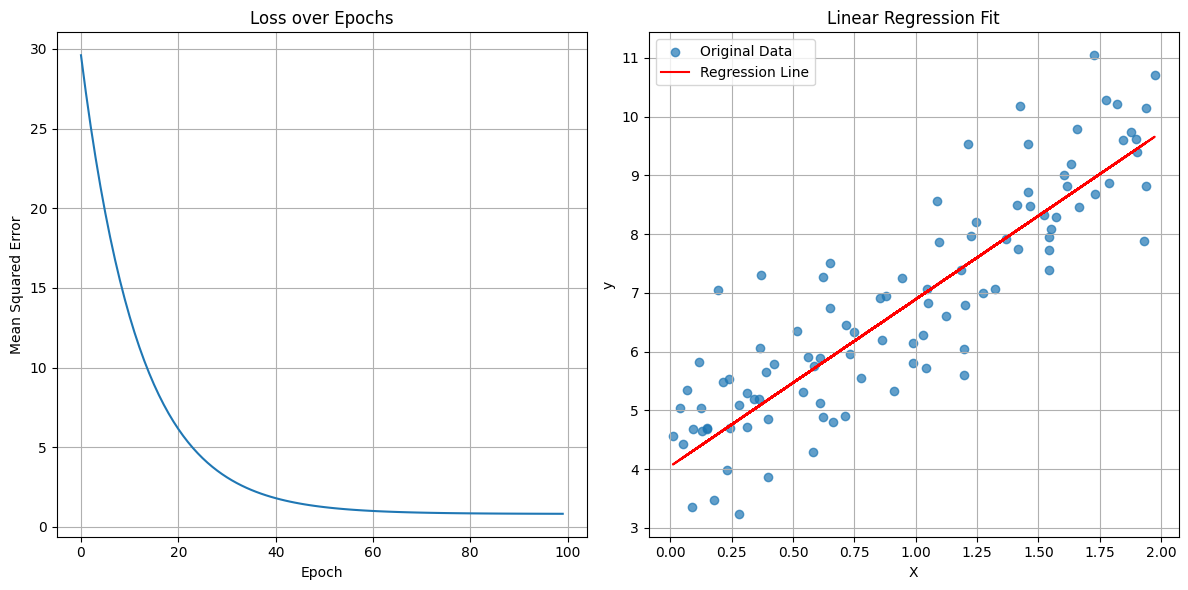

In [14]:
# Plot the loss over epochs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(epochs), losses)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)

# Plot the final regression line
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.7, label='Original Data')
plt.plot(X, X @ w + b, color='red', label='Regression Line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()